In [52]:
import os
import numpy as np
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, auc, accuracy_score
from tabpfn import TabPFNClassifier
import joblib

PAPER_FIGSIZE_COL = (3.45, 2.35)
PAPER_FIGSIZE_WIDE = (7.16, 2.65)
PAPER_FIGSIZE_TALL = (3.45, 3.2)
PAPER_PLOT_RC = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.title_fontsize": 7,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.35,
    "lines.linewidth": 1.35,
    "savefig.dpi": 600,
}
PAPER_COLOR_COUNT = "#2F6F73"
PAPER_COLOR_COMPARE = "#B85C38"
PAPER_COLOR_CLEAN = "#4F7F52"
PAPER_COLOR_ACCENT = "#8A6F2A"
PAPER_COLOR_LIGHT = "#F4F1E8"
PAPER_COLOR_INK = "#202020"
PAPER_CMAP = LinearSegmentedColormap.from_list("paper_count", [PAPER_COLOR_LIGHT, PAPER_COLOR_COUNT])
METHOD_DISPLAY_NAMES = {
    "alfa_svm": "ALFA SVM",
    "art_svm": "ART SVM",
    "badnets": "BadNets",
    "clean": "Clean",
    "feature_collision": "Feature Collision",
    "feature_noise_svm": "Feature Noise SVM",
    "learning_to_confuse": "Learning to Confuse",
    "metapoison": "MetaPoison",
    "poison_frogs": "Poison Frogs",
    "poissvm_svm": "PoisSVM",
    "random_flip_svm": "Random Flip SVM",
    "witches_brew": "Witches' Brew",
}
METHOD_ORDER = [
    "clean",
    "random_flip_svm",
    "alfa_svm",
    "feature_noise_svm",
    "feature_collision",
    "poissvm_svm",
    "art_svm",
    "learning_to_confuse",
    "metapoison",
    "witches_brew",
    "poison_frogs",
    "badnets",
]
METHOD_DISPLAY_ORDER = [METHOD_DISPLAY_NAMES[m] for m in METHOD_ORDER if m in METHOD_DISPLAY_NAMES]

sns.set_theme(style="whitegrid", context="paper", rc=PAPER_PLOT_RC)
plt.rcParams.update(PAPER_PLOT_RC)

# Setup Logging
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s [%(name)s] [%(levelname)s] %(message)s', 
    datefmt='%Y-%m-%d %H:%M:%S'
)
logger = logging.getLogger("LOAO_Unified_Benchmark")

# Helper Functions

In [53]:
def extract_base_dataset_name(dataname):
    if "_vs_" in dataname:
        part1 = dataname.split("_vs_")[0]
        return part1.rsplit("_", 1)[0]
    return dataname

In [54]:
def prepare_benchmark_data(db_path, seed, split_target='Is_Poisoned'):
    """
    Standardized data loading, filtering, and train-test splitting 
    (mimicking the original classification benchmark approach).
    """
    df = pd.read_csv(db_path)
    df['BaseGroup'] = df['Data'].apply(extract_base_dataset_name)

    # feature_noise_svm is considered clean
    df.loc[df['Method'] == 'feature_noise_svm', 'Is_Poisoned'] = 0
    df.loc[df['Method'] == 'feature_noise_svm', 'Method'] = 'clean'
    
    drop_cols = ['Data', 'Path', 'Method', 'Rate', 'Is_Poisoned', 'error', 'BaseGroup']
    drop_cols += [c for c in df.columns if c in ['Train.Clean', 'Test.Clean', 'Train.Poison', 'Test.Poison']]
    feature_cols = [c for c in df.columns if c not in drop_cols]
    
    logger.info(f"Using all {len(feature_cols)} available features.")

    df[feature_cols] = df[feature_cols].fillna(0)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(gss.split(df[feature_cols], df[split_target], df['BaseGroup']))
    
    train_df_full = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    # Leave out specific poisoners as defined in classification
    poisoner_to_leave_out = ["diva_attack_xgb", "diva_attack", "diva_attack2"]
    train_df_full = train_df_full[~(train_df_full['Method'].isin(poisoner_to_leave_out))]
    test_df = test_df[~(test_df['Method'].isin(poisoner_to_leave_out))]

    # Identify methods
    poisoners = sorted([m for m in train_df_full['Method'].unique() if m != 'clean'])
    all_methods = sorted(list(train_df_full['Method'].unique()))
    
    logger.info(f"Identified {len(poisoners)} poisoners to test: {poisoners}")
    
    return train_df_full, test_df, feature_cols, poisoners, all_methods

# Setup

In [55]:
db_path = "meta_db_universal.csv"
workers = 4
seed = 42
plots_dir = f"data/plots_detector"
os.makedirs(plots_dir, exist_ok=True)


📊 META-DATABASE STATISTICS: meta_db_universal.csv
Total Datasets Processed: 4818

--- ⚖️ Class & Domain Distribution ---
Clean (0):    961 (19.9%)
Poisoned (1): 3857 (80.1%)

Clean Baselines by Source:
  - HF: 467 (48.6%)
  - SYNTHETIC: 250 (26.0%)
  - OPENML: 244 (25.4%)

--- 🛡️ Breakdown by Method ---
Method
Clean                  961
Random Flip SVM        598
ALFA SVM               538
Feature Noise SVM      523
Feature Collision      354
PoisSVM                334
ART SVM                307
Learning to Confuse    261
MetaPoison             249
Witches' Brew          244
Poison Frogs           230
BadNets                219
Dataset Breakdown by Method (meta_db_universal.csv)
-> Saved method breakdown plot to: ./data/plots_metadb\meta_db_universal_method_dist.png

--- 📈 Rate Distribution per Method ---
Attack Count Heatmap: Method vs. Rate (meta_db_universal.csv)
-> Saved rate heatmap to: ./data/plots_metadb\meta_db_universal_rate_heatmap.png



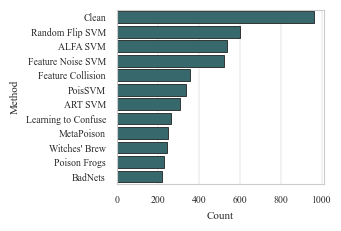

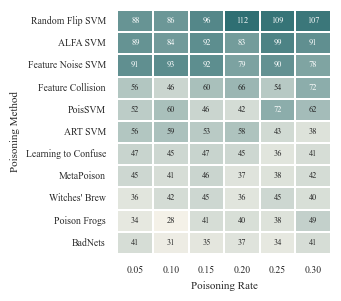

In [56]:
"""
Reads the MetaDB, prints comprehensive statistics regarding dataset balance,
and generates visual plots (bar chart for methods, heatmap for rates).
"""
if not os.path.exists(db_path):
    logger.error(f"Database not found at: {db_path}")
    
try:
    df = pd.read_csv(db_path)
except Exception as e:
    logger.error(f"Failed to read database: {e}")

plots_metadb_dir = "./data/plots_metadb"
os.makedirs(plots_metadb_dir, exist_ok=True)

print("\n" + "="*50)
print(f"📊 META-DATABASE STATISTICS: {os.path.basename(db_path)}")
print("="*50)

print(f"Total Datasets Processed: {len(df)}")

if 'Is_Poisoned' in df.columns:
    print("\n--- ⚖️ Class & Domain Distribution ---")
    clean_df = df[df['Is_Poisoned'] == 0].copy()
    clean_count = len(clean_df)
    pois_count = len(df[df['Is_Poisoned'] == 1])
    
    print(f"Clean (0):    {clean_count} ({clean_count/len(df):.1%})")
    print(f"Poisoned (1): {pois_count} ({pois_count/len(df):.1%})")
    
    # Dynamically extract sources from clean datasets
    def extract_source(data_name):
        if data_name.startswith('f0') or data_name.startswith('f1'):
            return 'synthetic'
        return data_name.split('_')[0].lower()
        
    clean_df['Source'] = clean_df['Data'].apply(extract_source)
    source_counts = clean_df['Source'].value_counts()
    
    print("\nClean Baselines by Source:")
    for src, count in source_counts.items():
        print(f"  - {src.upper()}: {count} ({count/clean_count:.1%})")

if 'Method' in df.columns:
    print("\n--- 🛡️ Breakdown by Method ---")
    method_counts = df['Method'].replace(METHOD_DISPLAY_NAMES).value_counts()
    method_counts = method_counts.reindex([m for m in METHOD_DISPLAY_ORDER if m in method_counts.index])
    print(method_counts.to_string())
    
    # Plot: Breakdown by Method (Fixed seaborn warning)
    plt.figure(figsize=PAPER_FIGSIZE_COL)
    ax_method = sns.barplot(x=method_counts.values, y=method_counts.index, color=PAPER_COLOR_COUNT, 
                            edgecolor=PAPER_COLOR_INK, linewidth=0.6)
    print(f"Dataset Breakdown by Method ({os.path.basename(db_path)})")
    plt.xlabel("Count")
    plt.ylabel("Method")
    plt.tight_layout()
    method_plot_path = os.path.join(plots_metadb_dir, f"{os.path.splitext(os.path.basename(db_path))[0]}_method_dist.png")
    plt.savefig(method_plot_path, dpi=300, bbox_inches='tight')
    print(f"-> Saved method breakdown plot to: {method_plot_path}")

if 'Method' in df.columns and 'Rate' in df.columns:
    print("\n--- 📈 Rate Distribution per Method ---")
    df_attacks = df[df['Method'] != 'clean'].copy()
    
    if not df_attacks.empty:
        df_attacks['Rate'] = df_attacks['Rate'].apply(lambda x: f"{x:.2f}")
        df_attacks['Method_Display'] = df_attacks['Method'].replace(METHOD_DISPLAY_NAMES)
        pivot = df_attacks.pivot_table(index='Method_Display', columns='Rate', aggfunc='size', fill_value=0)
        pivot = pivot.reindex([m for m in METHOD_DISPLAY_ORDER if m in pivot.index])
        
        # Plot: Heatmap of Rate Distribution
        plt.figure(figsize=(3.45, 3.05))
        sns.heatmap(pivot, annot=True, fmt='d', cmap=PAPER_CMAP, linewidths=0.35, 
                    linecolor='white', cbar=False, annot_kws={'fontsize': 6})
        print(f"Attack Count Heatmap: Method vs. Rate ({os.path.basename(db_path)})")
        plt.ylabel("Poisoning Method")
        plt.xlabel("Poisoning Rate")
        plt.tight_layout()
        heatmap_plot_path = os.path.join(plots_metadb_dir, f"{os.path.splitext(os.path.basename(db_path))[0]}_rate_heatmap.png")
        plt.savefig(heatmap_plot_path, dpi=300, bbox_inches='tight')
        print(f"-> Saved rate heatmap to: {heatmap_plot_path}")
    else:
        print("No attack methods found in the database.")
        
print("="*50 + "\n")

In [57]:
# Use centralized data preparation
train_df_full, test_df, feature_cols, poisoners, all_methods = prepare_benchmark_data(
    db_path, seed, split_target='Is_Poisoned'
)

# Re-append 'None' specific to classification setup (this trains on ALL data)
poisoners = ["None"]+poisoners

2026-05-28 16:09:23 [LOAO_Unified_Benchmark] [INFO] Using all 72 available features.
2026-05-28 16:09:23 [LOAO_Unified_Benchmark] [INFO] Identified 10 poisoners to test: ['alfa_svm', 'art_svm', 'badnets', 'feature_collision', 'learning_to_confuse', 'metapoison', 'poison_frogs', 'poissvm_svm', 'random_flip_svm', 'witches_brew']


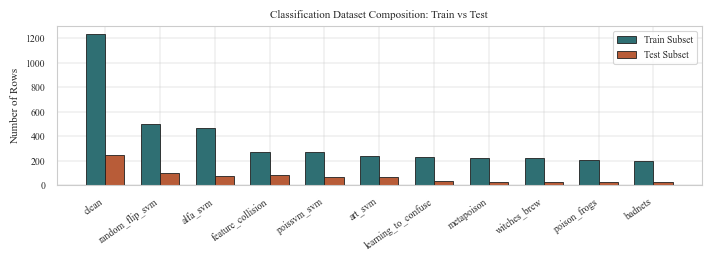

In [58]:
# Train/Test Distribution Plot
train_stats = train_df_full['Method'].value_counts().rename('Train')
test_stats = test_df['Method'].value_counts().rename('Test')
dist_df = pd.concat([train_stats, test_stats], axis=1).fillna(0)

sns.set_theme(style="whitegrid", context="paper", rc=PAPER_PLOT_RC)
fig_dist, ax_dist = plt.subplots(figsize=PAPER_FIGSIZE_WIDE)
x = np.arange(len(dist_df.index))
width = 0.35

bars1 = ax_dist.bar(x - width/2, dist_df['Train'], width, label='Train Subset', color=PAPER_COLOR_COUNT, edgecolor=PAPER_COLOR_INK, linewidth=0.6)
bars2 = ax_dist.bar(x + width/2, dist_df['Test'], width, label='Test Subset', color=PAPER_COLOR_COMPARE, edgecolor=PAPER_COLOR_INK, linewidth=0.6)

ax_dist.set_ylabel('Number of Rows')
ax_dist.set_title(f'Classification Dataset Composition: Train vs Test')
ax_dist.set_xticks(x)
ax_dist.set_xticklabels(dist_df.index, rotation=35, ha='right')
ax_dist.legend(frameon=True)

fig_dist.tight_layout()
dist_plot_path = os.path.join(plots_dir, "train_test_distribution.png")
fig_dist.savefig(dist_plot_path, dpi=300, bbox_inches='tight')

# Train

In [59]:
# TabPFN training disabled for plotting-only reruns. Uncomment this cell only to regenerate caches.
# loao_results = {}
# loao_global_results = {}
# all_test_preds = []
# optimal_threshold = 0.76
#
# for holdout in poisoners:
#     logger.info(f"🚀 Training Classification Model: [BLIND TO {holdout.upper()}]")
#     train_df = train_df_full[train_df_full['Method'] != holdout]
#     X_train, y_train = train_df[feature_cols], train_df['Is_Poisoned']
#     X_test = test_df[feature_cols]
#
#     scale_weight = len(y_train[y_train==0]) / max(1, len(y_train[y_train==1]))
#     clf = TabPFNClassifier(
#         n_estimators=32,
#         device='auto',
#         random_state=seed
#     )
#     clf.fit(X_train, y_train)
#
#     if holdout == "None":
#         model_path = "./data/binary_detector.joblib"
#         joblib.dump(clf, model_path)
#         logger.info(f"💾 Saved fully trained ALL DATA model to: {model_path}")
#
#     test_df_copy = test_df.copy()
#     test_df_copy['Prediction_Prob'] = clf.predict_proba(X_test)[:, 1]
#     test_df_copy['Prediction'] = (test_df_copy['Prediction_Prob'] >= optimal_threshold).astype(int)
#     test_df_copy['Prediction_Prob'] = clf.predict_proba(X_test)[:, 1]
#     test_df_copy['Holdout'] = holdout
#     all_test_preds.append(test_df_copy)
#
#     global_acc = accuracy_score(test_df_copy['Is_Poisoned'], test_df_copy['Prediction'])
#     loao_global_results[holdout] = global_acc
#
#     method_accs = {}
#     for method in all_methods:
#         mask = test_df_copy['Method'] == method
#         if mask.sum() > 0:
#             method_accs[method] = accuracy_score(test_df_copy.loc[mask, 'Is_Poisoned'], test_df_copy.loc[mask, 'Prediction'])
#         else:
#             method_accs[method] = 0.0
#
#     loao_results[holdout] = method_accs
#     logger.info(f"   => Zero-Shot Accuracy on {holdout}: {method_accs.get(holdout, 0):.2%}\n")
#     logger.info(f"   => Global Accuracy on {holdout}: {global_acc:.2%}\n")
#
# combined_preds = pd.concat(all_test_preds)
#
# # Isolate the probability scores of ONLY the genuinely clean datasets
# clean_probs = combined_preds[combined_preds['Is_Poisoned'] == 0]['Prediction_Prob']
#
# preds_all_train = combined_preds[combined_preds['Holdout'] == 'None'].copy()

In [60]:
# Load saved detector results from the GitHub checkpoint.
save_path = os.path.join("results", "detector_checkpoint.pkl")

loaded_results = joblib.load(save_path)

loao_results = loaded_results["loao_results"]
loao_global_results = loaded_results["loao_global_results"]
all_test_preds = loaded_results["all_test_preds"]
preds_all_train = loaded_results["preds_all_train"]

print(f"Results successfully loaded from {save_path}. You can now run the evaluation plot cells.")


Results successfully loaded from results\detector_checkpoint.pkl. You can now run the evaluation plot cells.


# Evaluate

Accuracy of Model Trained on ALL Data
(Green = Benign, Red = Poisoner)


C:\Users\kdo88\AppData\Local\Temp\ipykernel_15712\1662590299.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_all.set_xticklabels(ax_all.get_xticklabels(), rotation=35, ha='right')


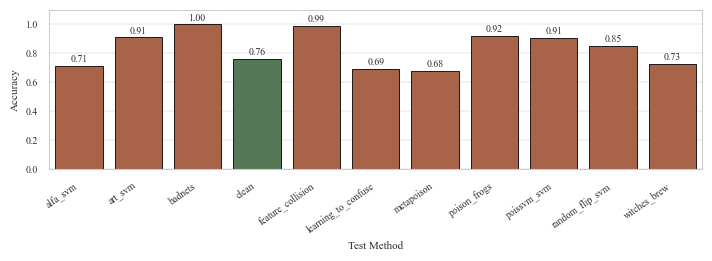

In [61]:
# --- Accuracy on All Methods (Poisoners + Clean/Noise) ---
method_accs_all = []
for method in all_methods:
    mask = preds_all_train['Method'] == method
    if mask.sum() > 0:
        acc = accuracy_score(preds_all_train.loc[mask, 'Is_Poisoned'], preds_all_train.loc[mask, 'Prediction'])
        method_accs_all.append({'Method': method, 'Accuracy': acc})

df_accs_all = pd.DataFrame(method_accs_all)

print("Accuracy of Model Trained on ALL Data\n(Green = Benign, Red = Poisoner)")

# Custom palette: Green for benign datasets, Red for poisoners
custom_palette = {m: PAPER_COLOR_CLEAN if m =='clean' else PAPER_COLOR_COMPARE for m in df_accs_all['Method']}

fig_all, ax_all = plt.subplots(figsize=PAPER_FIGSIZE_WIDE)
sns.barplot(data=df_accs_all, x='Method', y='Accuracy', ax=ax_all, palette=custom_palette, hue='Method', legend=False, edgecolor='black', linewidth=0.6)
ax_all.set_ylim(0, 1.1)
ax_all.set_ylabel("Accuracy")
ax_all.set_xlabel("Test Method")
ax_all.set_xticklabels(ax_all.get_xticklabels(), rotation=35, ha='right')

# Annotate exact accuracy on top of the bars
for p in ax_all.patches:
    ax_all.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), 
                    textcoords='offset points', fontsize=7)

plt.tight_layout()
fig_all.savefig(os.path.join(plots_dir, "accuracy_all_train_per_method.png"), dpi=300)

In [ ]:
"""
Standardized single horizontal bar plot (vertical figure) containing:
- Consistent semantic colors: all-data/count, comparison/LOAO, clean, and global/OOD
"""
sns.set_theme(style="whitegrid", context="paper", rc=PAPER_PLOT_RC)

# 'None' represents the model trained on ALL data in the run_classification_benchmark
actual_poisoners = [p for p in poisoners if p != "None"]

# Extract "All Data" evaluations safely
all_data_results = loao_results.get("None", {})
all_data_global = loao_global_results.get("None", 0.0)

# Prepare metrics matching the order of actual_poisoners
blue_scores = [all_data_results.get(p, 0.0) for p in actual_poisoners]
red_scores = [loao_results.get(p, {}).get(p, 0.0) for p in actual_poisoners]

# Extract overall metrics for Pristine and Global
clean_score = all_data_results.get("clean", 0.0)

# Dynamically scale height based on number of poisoners to maintain a vertical layout
fig_height = min(4.8, max(2.8, len(actual_poisoners) * 0.32 + 1.2))
fig, ax = plt.subplots(figsize=(7.16, fig_height))

y = np.arange(len(actual_poisoners))
height = 0.35

# 1. Plot Paired Poisoner Bars (Blue vs Red) - Using barh for horizontal bars
bars_blue = ax.barh(y - height/2, blue_scores, height, color=PAPER_COLOR_COUNT, edgecolor=PAPER_COLOR_INK, linewidth=0.6, label='Trained on All Data')
bars_red = ax.barh(y + height/2, red_scores, height, color=PAPER_COLOR_COMPARE, edgecolor=PAPER_COLOR_INK, linewidth=0.6, label='Trained on LOAO (Zero-Shot)')

# 2. Add Extra Bars for Pristine (Green) and Global (Orange) at the bottom
y_extra_1 = len(actual_poisoners)
y_extra_2 = len(actual_poisoners) + 1

bar_green = ax.barh(y_extra_1, clean_score, height, color=PAPER_COLOR_CLEAN, edgecolor=PAPER_COLOR_INK, linewidth=0.6, label='Pristine (Trained on All Data)')
bar_orange = ax.barh(y_extra_2, all_data_global, height, color=PAPER_COLOR_ACCENT, edgecolor=PAPER_COLOR_INK, linewidth=0.6, label='Global (Trained on All Data)')

# Set Y-axis ticks & labels
all_y = list(y) + [y_extra_1, y_extra_2]
y_labels = actual_poisoners + ['Pristine', 'Global']

ax.set_yticks(all_y)
ax.set_yticklabels(y_labels)

# Invert Y-axis so it reads top-to-bottom
ax.invert_yaxis()

# X-axis limits (using the y_limit variable passed into the function)
ax.set_xlim(0, 1.1)
ax.set_xlabel("Accuracy")

# Horizontal separator line to visually separate Specific Poisoners vs Global Summaries
if len(y) > 0:
    ax.axhline(y[-1] + 0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
# Place legend neatly outside the plot area
# Place legend neatly outside the plot area at the bottom on a single line
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    fontsize=7, 
    title="Evaluation Context", 
    title_fontsize=7
)

# 3. Add numerical value annotations at the end of every bar
for bars in [bars_blue, bars_red, bar_green, bar_orange]:
    for bar in bars:
        xval = bar.get_width()
        yval = bar.get_y() + bar.get_height() / 2
        ax.text(xval + (1.1 * 0.015), yval, f"{xval:.2f}", 
                ha='left', va='center', fontsize=6)
                
fig.tight_layout()

# Save & Track via Aim
target_plot_path = os.path.join(plots_dir, "loao_target_centric_summary.png")
fig.savefig(target_plot_path, dpi=300, bbox_inches='tight')

In [ ]:
fpr, tpr, _ = roc_curve(preds_all_train['Is_Poisoned'], preds_all_train['Prediction_Prob'])
roc_auc = auc(fpr, tpr)

print("Receiver Operating Characteristic (Standalone)")

plt.figure(figsize=PAPER_FIGSIZE_COL)
plt.plot(fpr, tpr, color=PAPER_COLOR_ACCENT, lw=1.4, marker='o', markevery=10, markersize=3, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='black', lw=1.0, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.55)
plt.tight_layout()

roc_output_path = "standalone_roc_curve.png"
plt.savefig(os.path.join(plots_dir, roc_output_path), dpi=300)

In [ ]:
# --- Average Accuracy Across All Poisoners broken down by Rate ---
# Filter out ALL benign methods since they don't have a meaningful poisoning rate
poison_preds = preds_all_train[~preds_all_train['Method'].isin(["clean"])].copy()
print("Average Global Accuracy Across All Poisoners by Rate")

if not poison_preds.empty:
    rate_accs = []
    # Group only by Rate to get the global average across all poisoners
    for rate, group in poison_preds.groupby('Rate'):
        acc = accuracy_score(group['Is_Poisoned'], group['Prediction'])
        rate_accs.append({'Rate': rate, 'Accuracy': acc})
        
    df_rate_accs = pd.DataFrame(rate_accs)
    df_rate_accs = df_rate_accs.sort_values(by='Rate')
    
    # Using lineplot for a single global curve
    fig_rate, ax_rate = plt.subplots(figsize=PAPER_FIGSIZE_COL)
    sns.lineplot(data=df_rate_accs, x='Rate', y='Accuracy', marker='o', 
                 linewidth=1.4, markersize=3.5, ax=ax_rate, color=PAPER_COLOR_COMPARE)
    
    ax_rate.set_ylim(0, 1.05)
    ax_rate.set_ylabel("Average Accuracy")
    ax_rate.set_xlabel("Poisoning Rate")
    
    plt.grid(True, linestyle='--', alpha=0.55)
    plt.tight_layout()
    
    fig_rate.savefig(os.path.join(plots_dir, "accuracy_all_train_by_rate_avg.png"), dpi=300)

In [ ]:
# =========================================================================
# Global vs. Clean Accuracy per Threshold Plot (0.05 Steps)
# =========================================================================
thresholds_to_test = np.arange(0.0, 1.05, 0.05)
global_accs = []
clean_accs_avg = []

for t in thresholds_to_test:
    # Apply current threshold (t)
    t_preds = (preds_all_train['Prediction_Prob'] >= t).astype(int)
    
    # 1. Global Accuracy
    global_acc = accuracy_score(preds_all_train['Is_Poisoned'], t_preds)
    global_accs.append(global_acc)
    
    # 2. Clean Accuracy (Now naturally includes feature_noise_svm)
    mask_clean = preds_all_train['Method'] == 'clean'
    
    acc_c = accuracy_score(
        preds_all_train.loc[mask_clean, 'Is_Poisoned'], 
        t_preds[mask_clean]
    ) if mask_clean.sum() > 0 else 0
    
    clean_accs_avg.append(acc_c)

# Generate the Plot
fig_acc_thresh, ax_acc_thresh = plt.subplots(figsize=PAPER_FIGSIZE_COL)

ax_acc_thresh.plot(thresholds_to_test, global_accs, 
                    label='Global Accuracy', color=PAPER_COLOR_ACCENT, linewidth=1.4, marker='o', markersize=3)
ax_acc_thresh.plot(thresholds_to_test, clean_accs_avg, 
                    label='Clean Accuracy', color=PAPER_COLOR_CLEAN, linewidth=1.4, marker='s', markersize=3, linestyle='--')

ax_acc_thresh.set_title(f"Accuracy vs. Decision Threshold")
ax_acc_thresh.set_xlabel("Decision Threshold")
ax_acc_thresh.set_ylabel("Accuracy")
ax_acc_thresh.set_xticks(np.arange(0.0, 1.05, 0.10))
ax_acc_thresh.set_xticklabels([f"{x:.1f}" for x in np.arange(0.0, 1.05, 0.10)])
ax_acc_thresh.set_xlim(0, 1)
ax_acc_thresh.set_ylim(0, 1.05)

ax_acc_thresh.legend(loc='lower left', frameon=True)
ax_acc_thresh.grid(True, linestyle='--', alpha=0.55)

plt.tight_layout()
acc_thresh_path = os.path.join(plots_dir, "accuracy_vs_threshold_steps.png")
fig_acc_thresh.savefig(acc_thresh_path, dpi=300)